<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aproximación de (99942) Apophis a la Tierra en abril de 2029
## Notebook principal (reporte de investigación en Mecánica Celeste)

*Soleil Dayana Niño Murcia - Universidad de Antioquia*

Este notebook estudia el sobrevuelo de (99942) Apophis en abril de 2029 como un problema de dinámica orbital jerárquica: primero como referencia kepleriana, luego como sistema restringido de tres cuerpos y, finalmente, como un problema N-cuerpos con efemérides reales. La pregunta no es solo cuándo ocurre el mínimo de distancia, sino cuánto cambia esa estimación cuando se incorporan más cuerpos y se refina la ventana temporal alrededor del encuentro.

# Tabla de Contenidos

- [Aproximación de (99942) Apophis a la Tierra en abril de 2029](#aproximación-de-99942-apophis-a-la-tierra-en-abril-de-2029)
  - [Notebook principal (reporte de investigación en Mecánica Celeste)](#notebook-principal-reporte-de-investigación-en-mecánica-celeste)
- [Pregunta de investigación y estrategia](#pregunta-de-investigación-y-estrategia)
- [Marco teórico escencial](#marco-teórico-escencial)
  - [1) Problema de N cuerpos](#1-problema-de-n-cuerpos)
  - [2) Magnitud observacional clave](#2-magnitud-observacional-clave)
  - [3) CRTBP](#3-crtbp)
  - [4) Ecuaciones de Gauss para variación orbital](#4-ecuaciones-de-gauss-para-variación-orbital)
- [0. Preparación del entorno](#0-preparación-del-entorno)
- [1. Simulación principal y convergencia entre versiones de modelo](#1-simulación-principal-y-convergencia-entre-versiones-de-modelo)
- [2. Bloque de dos cuerpos: referencia kepleriana e interpretación del hodógrafo](#2-bloque-de-dos-cuerpos-referencia-kepleriana-e-interpretación-del-hodógrafo)
- [3. Bloque de tres cuerpos: lectura energética con Jacobi (marco CRTBP)](#3-bloque-de-tres-cuerpos-lectura-energética-con-jacobi-marco-crtbp)
- [4. Perturbaciones terrestres y ecuaciones de Gauss: variación de i y Ω](#4-perturbaciones-terrestres-y-ecuaciones-de-gauss-variación-de-i-y-ω)
- [5. Síntesis de hallazgos, limitaciones y extensiones](#5-síntesis-de-hallazgos-limitaciones-y-extensiones)
  - [Hallazgos principales](#hallazgos-principales)
  - [Limitaciones del presente reporte](#limitaciones-del-presente-reporte)
  - [Extensiones futuras recomendadas](#extensiones-futuras-recomendadas)

Acrónimos y conceptos clave:

| Acrónimo | Definición | Uso en este notebook |
|:--|:--|:--|
| **SEA** | Sol–Tierra–Apophis | Modelo mínimo para aislar el efecto dominante de la Tierra |
| **SEMA** | Sol–Tierra–Luna–Apophis | Añade la contribución lunar al sobrevuelo |
| **SEMAJ** | Sol–Tierra–Luna–Júpiter–Apophis | Mide el efecto acumulado de un perturbador lejano masivo |
| **SEMAJV** | Sol–Tierra–Luna–Júpiter–Venus–Apophis | Refina la comparación al incluir otro planetesimal interior |
| **9C** | Modelo completo con Mercurio, Venus, Tierra, Luna, Marte, Júpiter, Saturno y Apophis | Referencia final de mayor fidelidad |
| **CRTBP** | Problema Restringido Circular de Tres Cuerpos | Marco analítico para leer la geometría energética del encuentro |
| **NEA** | Near-Earth Asteroid | Categoría dinámica de Apophis |

Las siglas SEA, SEMA, SEMAJ y SEMAJV son notación propia del proyecto y se usan solo como etiquetas de complejidad progresiva; no reemplazan la formulación física completa de cada sistema.

### Introducción y motivación

El acercamiento de **(99942) Apophis** a la Tierra en abril de 2029 constituye un caso especialmente útil para estudiar, con herramientas de mecánica celeste, cómo una predicción orbital cambia cuando el modelo físico gana detalle. La trayectoria dominante sigue estando guiada por la gravedad del Sol, pero en la ventana del encuentro aparecen efectos que ya no conviene tratar como un fondo uniforme: la Tierra, la Luna y los planetas interiores modifican la estimación de la distancia mínima y la lectura dinámica del evento.

Por eso, este reporte no se limita a una sola simulación. La idea es mostrar, paso a paso, cómo se comporta la aproximación de Apophis cuando se comparan modelos de distinta complejidad, desde referencias keplerianas y el CRTBP hasta un esquema N-cuerpos más completo. Esa comparación es la base para responder con cuidado dos preguntas sencillas pero centrales: cuándo ocurre el mínimo de distancia y qué tan estable es esa estimación al cambiar el modelo.

## 1. Pregunta de investigación y estrategia

**Pregunta central:** ¿cómo cambia la estimación de la distancia mínima Tierra–Apophis y la interpretación dinámica del encuentro de 2029 cuando pasamos de un modelo mínimo a un modelo N-cuerpos completo?

**Estrategia de trabajo:**

- obtener las condiciones iniciales desde **NASA Horizons** en un marco baricéntrico;
- expresar el problema en unidades canónicas para estabilizar la integración y comparar modelos de distinta complejidad;
- contrastar de forma explícita los modelos **SEA → SEMA → SEMAJ → SEMAJV → 9C**;
- refinar temporalmente la ventana alrededor del mínimo para no depender solo de la resolución global;
- validar la interpretación física con tres marcos complementarios del curso: dos cuerpos, CRTBP/Jacobi y ecuaciones de Gauss.

El objetivo es, además de obtener una fecha y una distancia, comprobar qué gana y qué pierde cada aproximación cuando se emplea para describir el mismo fenómeno.

## 2. Marco teórico esencial

### 2.1 Definición de los modelos de complejidad progresiva
Para cuantificar el impacto de cada perturbador, definimos los siguientes modelos:
- **SEA (3C):** Sol-Tierra-Apophis.
- **SEMA (4C):** Sol-Tierra-Luna-Apophis.
- **SEMAJ (5C):** Añade a Júpiter.
- **SEMAJV (6C):** Añade a Venus.
- **9C Final:** Sistema solar completo hasta Saturno.

### 2.2 Problema de N cuerpos
La dinámica gravitacional para cada cuerpo $i$ se modela por:

$$\ddot{\mathbf r}_i = -\,G\sum_{j \neq i} m_j\,\frac{\mathbf r_i-\mathbf r_j}{\|\mathbf r_i-\mathbf r_j\|^3}.$$

### 2.3 Magnitud observacional clave
La variable principal es la distancia Tierra–Apophis: $d_{EA}(t)=\|\mathbf r_{A}(t)-\mathbf r_{E}(t)\|$.

## 3. Metodología: preparación del entorno y unidades

Establecemos el marco de trabajo en unidades canónicas para asegurar estabilidad numérica, trazabilidad de supuestos y comparabilidad entre modelos.

In [1]:
%pip install -Uq pymcel scipy

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

Importamos librerías de cálculo, visualización e integración. En la siguiente celda definimos las constantes físicas y las rutinas comunes para no repetir código en cada experimento.

In [2]:
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import cumulative_trapezoid

import pymcel as pc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


Aquí fijamos las unidades canónicas, los parámetros gravitacionales y la semilla geométrica de respaldo. El respaldo no sustituye a Horizons: solo permite que el cuaderno siga siendo ejecutable si la consulta remota falla.

In [3]:
# --- Unidades canónicas ---
AU_m = pc.constantes.au
AU_km = AU_m / 1e3
M_sun_kg = pc.constantes.M_sun
G_SI = pc.constantes.G
R_Earth_km = 6371.0

UT_s = np.sqrt(AU_m**3 / (G_SI * M_sun_kg))
UT_days = UT_s / 86400.0
vel_unit = AU_km / UT_s

# --- Parámetros gravitacionales ---
GM = {
    'Sol':      1.32712440018e11,
    'Mercurio': 2.2032e4,
    'Venus':    3.24858592e5,
    'Tierra':   3.986004418e5,
    'Luna':     4.9048695e3,
    'Marte':    4.282837e4,
    'Jupiter':  1.26686534e8,
    'Saturno':  3.7931187e7,
}
M_apophis_kg = 2.7e10

masas_canon = {k: v / GM['Sol'] for k, v in GM.items()}
masas_canon['Apophis'] = M_apophis_kg / M_sun_kg

def estados_fallback_aprox():
    """Estados aproximados en canónicas para ejecutar sin acceso a Horizons."""
    deg = np.pi / 180.0
    elems = {
        'Mercurio': (0.3871, 0.2056, 7.0,   48.3,  29.1, 250.0),
        'Venus':    (0.7233, 0.0068, 3.39,  76.7,  54.9,  50.0),
        'Tierra':   (1.0000, 0.0167, 0.00, -11.3, 102.9, 100.0),
        'Marte':    (1.5237, 0.0934, 1.85,  49.6, 286.5, 355.0),
        'Jupiter':  (5.2044, 0.0489, 1.30, 100.5, 273.9,  30.0),
        'Saturno':  (9.5826, 0.0565, 2.49, 113.7, 339.4, 320.0),
        'Apophis':  (0.9224, 0.1911, 3.34, 204.4, 126.4, 170.0),
    }
    estados = {'Sol': {'r': [0, 0, 0], 'v': [0, 0, 0]}}
    for nombre, (a, e, i, W, w, f) in elems.items():
        p = a * (1 - e**2)
        est = pc.elementos_a_estado(1.0, np.array([p, e, i*deg, W*deg, w*deg, f*deg]))
        estados[nombre] = {'r': est[:3], 'v': est[3:]}
    rE = np.array(estados['Tierra']['r']); vE = np.array(estados['Tierra']['v'])
    er = rE / np.linalg.norm(rE); zhat = np.array([0.0, 0.0, 1.0])
    et = np.cross(zhat, er); et = et / np.linalg.norm(et)
    rho = 384400.0 / AU_km; phi = 40.0 * deg
    r_rel = rho * (np.cos(phi) * er + np.sin(phi) * et)
    v_rel_mag = np.sqrt((masas_canon['Tierra'] + masas_canon['Luna']) / rho)
    v_rel = v_rel_mag * (-np.sin(phi) * er + np.cos(phi) * et)
    estados['Luna'] = {'r': rE + r_rel, 'v': vE + v_rel}
    return estados

In [4]:
ids_horizons = {
    'Sol': '10', 'Mercurio': '199', 'Venus': '299', 'Tierra': '399',
    'Luna': '301', 'Marte': '499', 'Jupiter': '599', 'Saturno': '699',
    'Apophis': '99942'
}

print(f'UT = {UT_days:.6f} días | 1 AU/UT = {vel_unit:.6f} km/s')

UT = 58.132441 días | 1 AU/UT = 29.784692 km/s


## 4. Resultados y análisis

### 4.1 Convergencia de modelos

Comparamos las predicciones de cada familia de modelos para observar cómo se estabiliza la distancia mínima al incorporar más cuerpos masivos.

In [5]:
def extraer_estado_canonico(tabla_o_dict):
    if isinstance(tabla_o_dict, dict):
        return np.array(tabla_o_dict['r'], dtype=float), np.array(tabla_o_dict['v'], dtype=float)
    row = tabla_o_dict[0]
    r = np.array([float(row['x']), float(row['y']), float(row['z'])], dtype=float)
    v = np.array([float(row['vx']), float(row['vy']), float(row['vz'])], dtype=float)
    return r, v * UT_days

def descargar_estados(epoch, nombres):
    estados = {}
    try:
        for nombre in nombres:
            estados[nombre] = pc.consulta_horizons(id=ids_horizons[nombre], location='@0', epochs=epoch, datos='vectors', propiedades='default')[0]
        print('Consulta Horizons completada.')
    except Exception as e:
        fallback = estados_fallback_aprox()
        for nombre in nombres: estados[nombre] = fallback[nombre]
    return estados

def correr_modelo(orden, estados, duracion_dias=547, n_pasos=1800):
    ts = np.linspace(0.0, duracion_dias / UT_days, n_pasos)
    idx = {n: k for k, n in enumerate(orden)}
    sistema = []
    for nombre in orden:
        r, v = extraer_estado_canonico(estados[nombre])
        sistema.append(dict(m=masas_canon[nombre], r=list(r), v=list(v)))
    rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema, ts)
    d = np.linalg.norm(rs[idx['Tierra']] - rs[idx['Apophis']], axis=1)
    return {'orden': orden, 'idx': idx, 'ts': ts, 'rs': rs, 'vs': vs, 'rps': rps, 'vps': vps, 'const': const, 'dist': d, 'i_min': int(np.argmin(d)), 'd_min_AU': float(np.min(d))}

In [6]:
T0_STR = '2028-01-01'
t0_date = datetime(2028, 1, 1)
orden_superset = ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Apophis']
estados_t0 = descargar_estados(T0_STR, orden_superset)

modelos = {
    'SEA (3C)': ['Sol', 'Tierra', 'Apophis'],
    'SEMA (4C)': ['Sol', 'Tierra', 'Luna', 'Apophis'],
    'SEMAJ (5C)': ['Sol', 'Tierra', 'Luna', 'Jupiter', 'Apophis'],
    'SEMAJV (6C)': ['Sol', 'Tierra', 'Luna', 'Jupiter', 'Venus', 'Apophis'],
    '9C final': ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Apophis'],
}

resultados = {nombre: correr_modelo(orden, estados_t0) for nombre, orden in modelos.items()}

tabla = []
for nombre, res in resultados.items():
    i = res['i_min']
    fecha = t0_date + timedelta(days=float(res['ts'][i] * UT_days))
    tabla.append([nombre, res['d_min_AU'], res['d_min_AU'] * AU_km, fecha])

df_conv = pd.DataFrame(tabla, columns=['Modelo', 'd_min_AU', 'd_min_km', 'fecha_min']).sort_values('d_min_km').reset_index(drop=True)
display(df_conv)

Consulta Horizons completada.


,Modelo,d_min_AU,d_min_km,fecha_min
0,9C final,0.000320,47858.625084,2029-04-13 20:34:17.142857
1,SEMAJV (6C),0.000323,48260.409147,2029-04-13 20:34:17.142857
2,SEMAJ (5C),0.000349,52141.179331,2029-04-13 20:34:17.142857
3,SEMA (4C),0.000360,53912.798381,2029-04-13 20:34:17.142857
4,SEA (3C),0.005025,751715.140054,2029-04-14 11:09:58.332407


Graficamos la convergencia para visualizar de manera directa el efecto de incorporar más física al sistema. La expectativa es que los modelos más completos estabilicen la predicción de distancia mínima.


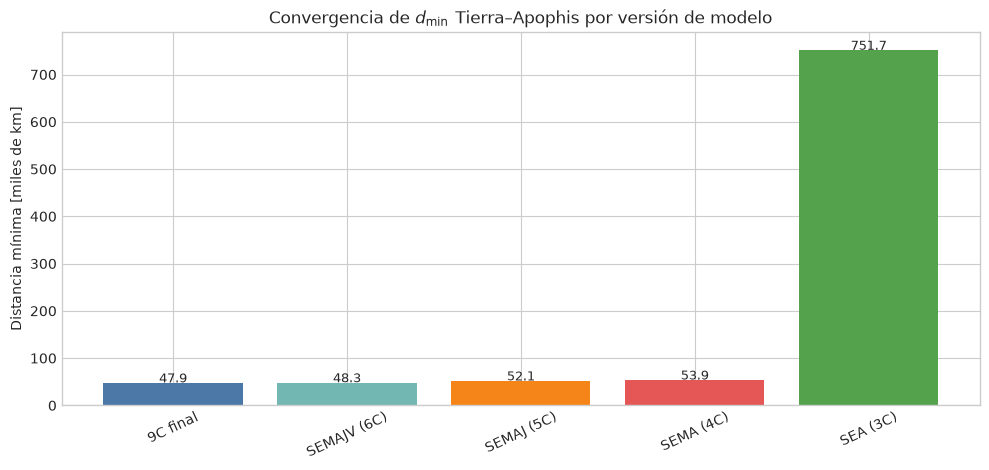

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(df_conv['Modelo'], df_conv['d_min_km'] / 1000, color=['#4c78a8', '#72b7b2', '#f58518', '#e45756', '#54a24b'])
ax.set_ylabel('Distancia mínima [miles de km]')
ax.set_title('Convergencia de $d_{\min}$ Tierra–Apophis por versión de modelo')
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(df_conv['d_min_km'] / 1000):
    ax.text(i, v + 0.6, f'{v:,.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### 4.2 Refinamiento Temporal del Encuentro (9 Cuerpos)
Una vez identificado el modelo más completo, aumentamos la resolución temporal para determinar con precisión la fecha y distancia del máximo acercamiento.

En simulaciones de N-cuerpos que cubren meses o años, un paso temporal global suele ser suficiente para seguir la órbita en términos gruesos. El problema aparece cerca del encuentro: allí la distancia cambia con rapidez y el instante exacto del mínimo puede quedar mal representado si no se aumenta la resolución.

El **refinamiento temporal local** consiste en tomar la ventana donde la corrida global ya ubica el acercamiento, reintegrar solo ese tramo con más puntos y medir de nuevo la distancia mínima. En este proyecto eso se hace con el modelo de 9 cuerpos, porque es la referencia más completa y la que mejor sostiene la interpretación final del evento.

In [8]:
res9 = resultados['9C final']
idx9 = res9['idx']

MARGEN_DIAS = 30
N_FINO = 4200

ts = res9['ts']
rs = res9['rs']
vs = res9['vs']
i_min = res9['i_min']

# Ventana local en UT
t_ini = max(0.0, ts[i_min] - MARGEN_DIAS / UT_days)
t_fin = min(ts[-1], ts[i_min] + MARGEN_DIAS / UT_days)
i_restart = int(np.argmin(np.abs(ts - t_ini)))

orden9 = res9['orden']
sistema_fino = []
for nombre in orden9:
    k = idx9[nombre]
    sistema_fino.append(dict(m=masas_canon[nombre], r=list(rs[k, i_restart, :]), v=list(vs[k, i_restart, :])))

ts_rel = np.linspace(0.0, t_fin - t_ini, N_FINO)
rs_f, vs_f, _, _, const_f = pc.ncuerpos_solucion(sistema_fino, ts_rel)

dist_f = np.linalg.norm(rs_f[idx9['Tierra']] - rs_f[idx9['Apophis']], axis=1)
i_min_f = int(np.argmin(dist_f))

fecha_min_f = t0_date + timedelta(days=float((t_ini + ts_rel[i_min_f]) * UT_days))
d_min_f_AU = float(dist_f[i_min_f])
d_min_f_km = d_min_f_AU * AU_km
d_min_f_RE = d_min_f_km / R_Earth_km

print(f'Distancia mínima refinada = {d_min_f_AU:.6e} AU = {d_min_f_km:,.0f} km = {d_min_f_RE:.2f} R_⊕')
print(f'Fecha refinada            = {fecha_min_f:%Y-%m-%d %H:%M UTC}')


Distancia mínima refinada = 2.564956e-04 AU = 38,371 km = 6.02 R_⊕
Fecha refinada            = 2029-04-14 00:10 UTC


Mostramos tres visualizaciones centrales del modelo final: (i) curva de distancia con zoom en el mínimo, (ii) conservación de energía como control numérico y (iii) trayectorias XY para contexto orbital global.


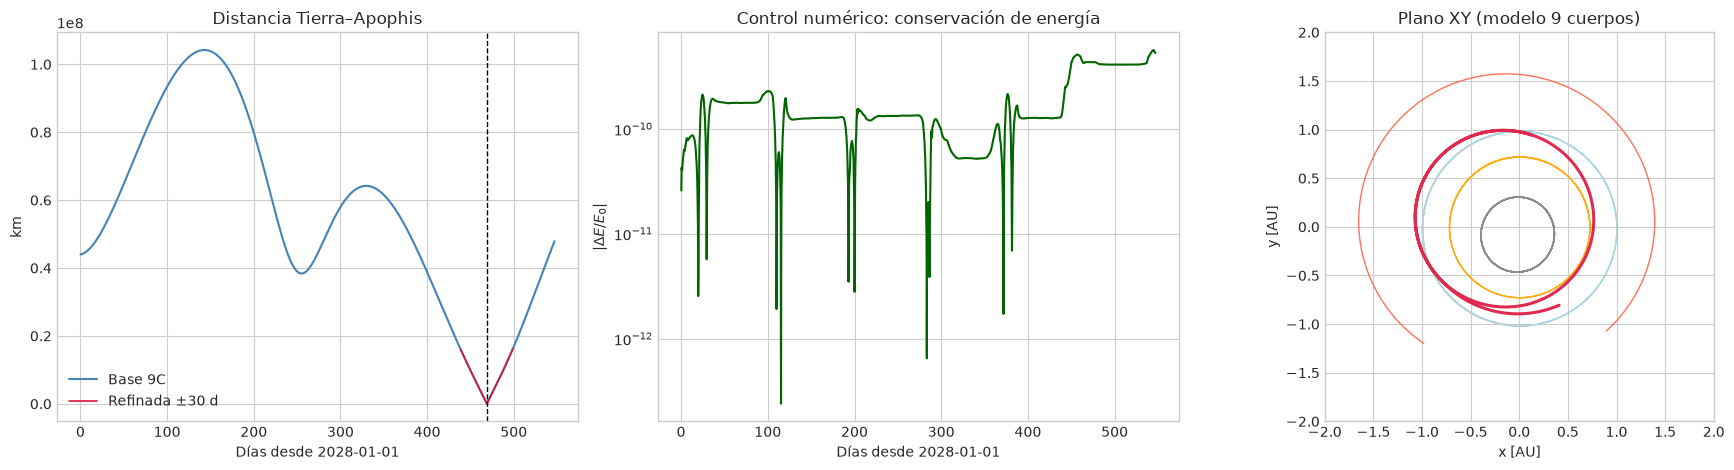

In [9]:
dias = ts * UT_days
dias_f = (t_ini + ts_rel) * UT_days

E9 = res9['const']['K'] + res9['const']['U']
err_E = np.abs((E9 - E9[0]) / E9[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Distancia
axes[0].plot(dias, res9['dist'] * AU_km, color='steelblue', lw=1.5, label='Base 9C')
axes[0].plot(dias_f, dist_f * AU_km, color='crimson', lw=1.2, label='Refinada ±30 d')
axes[0].axvline(dias_f[i_min_f], color='k', ls='--', lw=1)
axes[0].set_title('Distancia Tierra–Apophis')
axes[0].set_xlabel('Días desde 2028-01-01')
axes[0].set_ylabel('km')
axes[0].legend()

# Energía
axes[1].semilogy(dias[1:], err_E[1:] + 1e-20, color='darkgreen')
axes[1].set_title('Control numérico: conservación de energía')
axes[1].set_xlabel('Días desde 2028-01-01')
axes[1].set_ylabel(r'$|\Delta E / E_0|$')

# Plano XY
col = {
    'Sol': 'gold', 'Mercurio': 'gray', 'Venus': 'orange', 'Tierra': 'deepskyblue', 'Luna': 'lightgray',
    'Marte': 'tomato', 'Jupiter': 'sandybrown', 'Saturno': 'khaki', 'Apophis': 'crimson'
}
for nombre in orden9:
    k = idx9[nombre]
    lw = 2.2 if nombre == 'Apophis' else 1.0
    axes[2].plot(rs[k, :, 0], rs[k, :, 1], color=col[nombre], lw=lw, alpha=0.9)
axes[2].set_aspect('equal', 'box')
axes[2].set_xlim(-2.0, 2.0)
axes[2].set_ylim(-2.0, 2.0)
axes[2].set_xlabel('x [AU]')
axes[2].set_ylabel('y [AU]')
axes[2].set_title('Plano XY (modelo 9 cuerpos)')

plt.tight_layout()
plt.show()


### 4.3 Análisis de Dos Cuerpos: Referencia Kepleriana y Hodógrafo
Utilizamos el hodógrafo para visualizar la desviación de la velocidad respecto al círculo ideal kepleriano durante el encuentro.

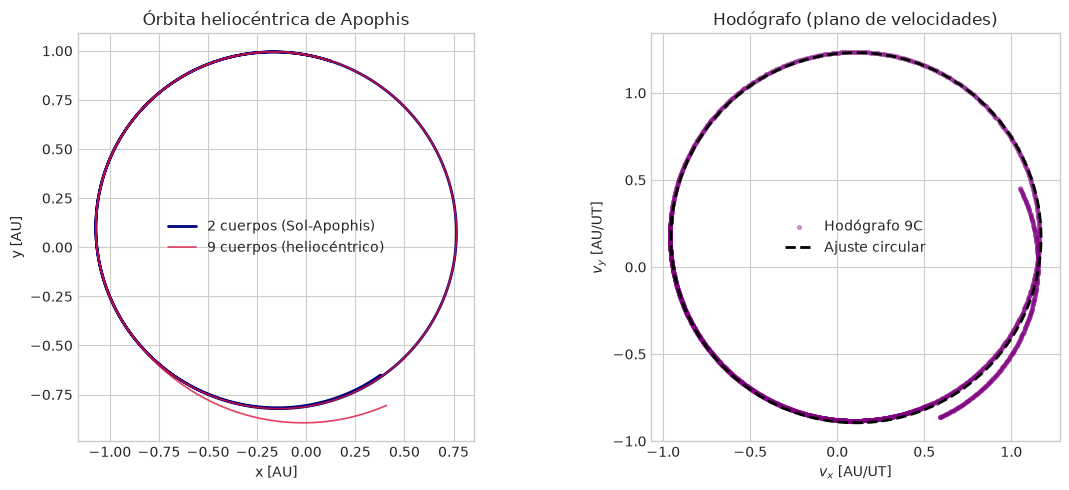

In [10]:
res2 = correr_modelo(['Sol', 'Tierra', 'Apophis'], estados_t0, duracion_dias=547, n_pasos=1700)
idx2 = res2['idx']

# Trayectoria heliocéntrica de Apophis en 2C vs 9C
rA_2 = res2['rs'][idx2['Apophis']] - res2['rs'][idx2['Sol']]
rA_9 = rs[idx9['Apophis']] - rs[idx9['Sol']]

# Hodógrafo a partir de velocidades heliocéntricas en 9C
vA_9 = vs[idx9['Apophis']] - vs[idx9['Sol']]
vxy = vA_9[:, :2]

# Ajuste de círculo (x^2 + y^2 + Ax + By + C = 0)
X = np.column_stack([vxy[:, 0], vxy[:, 1], np.ones(len(vxy))])
y = -(vxy[:, 0]**2 + vxy[:, 1]**2)
A, B, C = np.linalg.lstsq(X, y, rcond=None)[0]
xc, yc = -A/2, -B/2
R = np.sqrt(max(0.0, xc**2 + yc**2 - C))

th = np.linspace(0, 2*np.pi, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(rA_2[:, 0], rA_2[:, 1], color='navy', lw=2, label='2 cuerpos (Sol-Apophis)')
axes[0].plot(rA_9[:, 0], rA_9[:, 1], color='crimson', lw=1.2, alpha=0.8, label='9 cuerpos (heliocéntrico)')
axes[0].set_aspect('equal', 'box')
axes[0].set_xlabel('x [AU]')
axes[0].set_ylabel('y [AU]')
axes[0].set_title('Órbita heliocéntrica de Apophis')
axes[0].legend()

axes[1].scatter(vxy[:, 0], vxy[:, 1], s=7, alpha=0.35, color='purple', label='Hodógrafo 9C')
axes[1].plot(xc + R*np.cos(th), yc + R*np.sin(th), 'k--', lw=2, label='Ajuste circular')
axes[1].set_aspect('equal', 'box')
axes[1].set_xlabel(r'$v_x$ [AU/UT]')
axes[1].set_ylabel(r'$v_y$ [AU/UT]')
axes[1].set_title('Hodógrafo (plano de velocidades)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.4 Lectura Energética: Marco CRTBP y Jacobi
Analizamos si el asteroide tiene energía suficiente para 'cruzar' las puertas de los puntos de Lagrange $L_1$ y $L_2$ mediante sus curvas de velocidad cero.

In [11]:
def omega_eff(x, y, mu):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2)
    return (1 - mu) / r1 + mu / r2 + 0.5 * (x**2 + y**2)


def jacobi(x, y, vx, vy, mu):
    return 2.0 * omega_eff(x, y, mu) - (vx**2 + vy**2)


def f_colineal(x, mu):
    return x - (1-mu)*(x+mu)/abs(x+mu)**3 - mu*(x-1+mu)/abs(x-1+mu)**3

mu = masas_canon['Tierra'] / (masas_canon['Sol'] + masas_canon['Tierra'])

# Estado cercano al mínimo refinado (usamos corrida fina 9C)
rS = rs_f[idx9['Sol'], i_min_f]
rE = rs_f[idx9['Tierra'], i_min_f]
rA = rs_f[idx9['Apophis'], i_min_f]
vS = vs_f[idx9['Sol'], i_min_f]
vE = vs_f[idx9['Tierra'], i_min_f]
vA = vs_f[idx9['Apophis'], i_min_f]

rST = rE - rS
dST = np.linalg.norm(rST)
x_hat = rST / dST

vST = vE - vS
hvec = np.cross(rST, vST)
z_hat = hvec / np.linalg.norm(hvec)
y_hat = np.cross(z_hat, x_hat)

omega_vec = hvec / (dST**2)
omega_mag = np.linalg.norm(omega_vec)

r_cm = (1 - mu) * rS + mu * rE
v_cm = (1 - mu) * vS + mu * vE

r_rel = rA - r_cm
v_rel = vA - v_cm
v_rot = v_rel - np.cross(omega_vec, r_rel)

x = np.dot(r_rel, x_hat) / dST
y = np.dot(r_rel, y_hat) / dST
vx = np.dot(v_rot, x_hat) / (dST * omega_mag)
vy = np.dot(v_rot, y_hat) / (dST * omega_mag)

CJ_apo = jacobi(x, y, vx, vy, mu)
L1 = brentq(lambda xx: f_colineal(xx, mu), 0.5, 1-mu-1e-5)
L2 = brentq(lambda xx: f_colineal(xx, mu), 1-mu+1e-5, 1.5)
CJ_L1 = jacobi(L1, 0.0, 0.0, 0.0, mu)
CJ_L2 = jacobi(L2, 0.0, 0.0, 0.0, mu)

print(f'mu (Sol-Tierra) = {mu:.6e}')
print(f'C_J(Apophis) = {CJ_apo:.6f}')
print(f'C_J(L1)      = {CJ_L1:.6f}')
print(f'C_J(L2)      = {CJ_L2:.6f}')


mu (Sol-Tierra) = 3.003481e-06
C_J(Apophis) = 2.972947
C_J(L1)      = 3.000891
C_J(L2)      = 3.000887


Visualizamos curvas de velocidad cero en un zoom de la región terrestre para contextualizar geométricamente el valor de Jacobi calculado para Apophis.


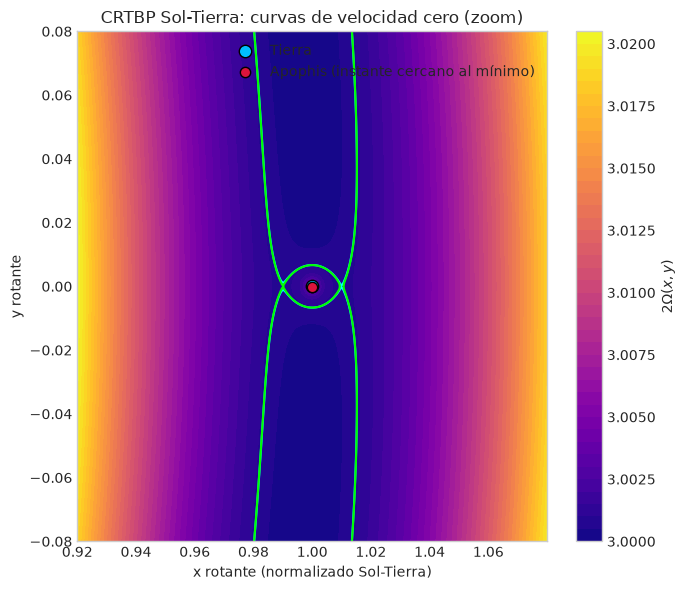

In [12]:
xg = np.linspace(1-mu-0.08, 1-mu+0.08, 350)
yg = np.linspace(-0.08, 0.08, 350)
X, Y = np.meshgrid(xg, yg)
CJ_map = np.clip(2 * omega_eff(X, Y, mu), 2.0, 5.0)

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(X, Y, CJ_map, levels=40, cmap='plasma')
niveles = sorted(set([CJ_apo, CJ_L1, CJ_L2]))
ax.contour(X, Y, CJ_map, levels=niveles, colors=['white', 'cyan', 'lime'][:len(niveles)], linewidths=1.5)
ax.scatter([1-mu], [0], color='deepskyblue', s=80, edgecolor='k', label='Tierra')
ax.scatter([x], [y], color='crimson', s=55, edgecolor='k', label='Apophis (instante cercano al mínimo)')
ax.set_xlabel('x rotante (normalizado Sol-Tierra)')
ax.set_ylabel('y rotante')
ax.set_title('CRTBP Sol-Tierra: curvas de velocidad cero (zoom)')
ax.legend(loc='upper right')
fig.colorbar(cs, ax=ax, label=r'$2\Omega(x,y)$')
plt.tight_layout()
plt.show()


### 4.5 Dinámica Perturbativa: Ecuaciones de Gauss
Validamos físicamente el cambio en la geometría de la órbita (inclinación y nodo) integrando las aceleraciones perturbadoras de la Tierra.

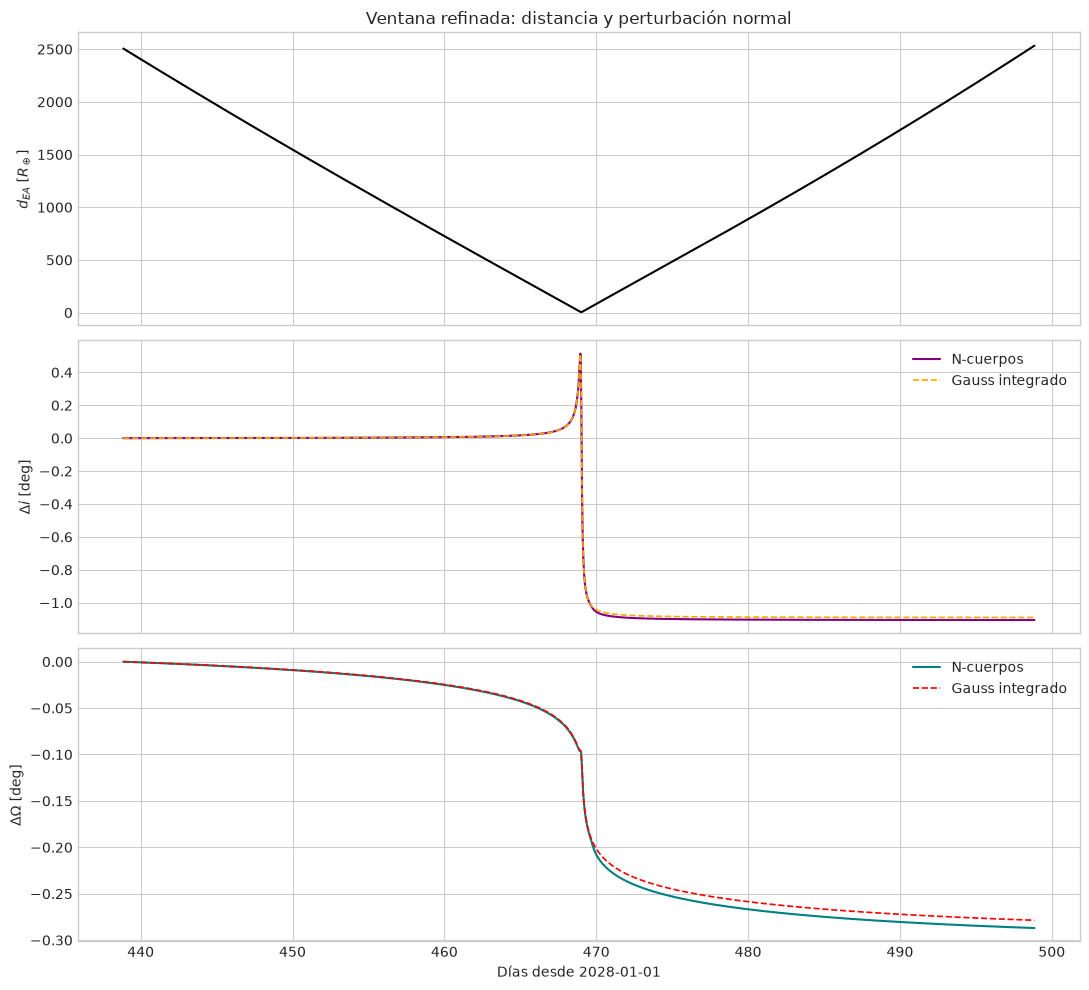

In [13]:
# Estados heliocéntricos (modelo refinado)
rA = rs_f[idx9['Apophis']] - rs_f[idx9['Sol']]
vA = vs_f[idx9['Apophis']] - vs_f[idx9['Sol']]
rE = rs_f[idx9['Tierra']] - rs_f[idx9['Sol']]

N = len(ts_rel)
aT = np.zeros((N, 3))
for k in range(N):
    dr = rE[k] - rA[k]
    d = np.linalg.norm(dr)
    aT[k] = masas_canon['Tierra'] * dr / d**3

# Elementos osculadores desde N-cuerpos
elts = np.full((N, 6), np.nan)
for k in range(N):
    estado = np.concatenate([rA[k], vA[k]])
    try:
        elts[k] = pc.estado_a_elementos(1.0, estado)  # mu_sol = 1 en canónicas
    except Exception:
        pass

p, e, inc, Omega, omega, f_true = [elts[:, j] for j in range(6)]
r_norm = np.linalg.norm(rA, axis=1)
h_vec = np.cross(rA, vA)
h_norm = np.linalg.norm(h_vec, axis=1)
w_hat = h_vec / h_norm[:, None]
W = np.einsum('ij,ij->i', aT, w_hat)

arg = omega + f_true
sin_i = np.sin(inc)

with np.errstate(divide='ignore', invalid='ignore'):
    didt = (r_norm * np.cos(arg) / h_norm) * W
    dOdt = (r_norm * np.sin(arg) / (h_norm * sin_i)) * W

# Integración temporal de Gauss (desplazamientos relativos)
i_gauss = inc[0] + cumulative_trapezoid(np.nan_to_num(didt), ts_rel, initial=0.0)
O_gauss = Omega[0] + cumulative_trapezoid(np.nan_to_num(dOdt), ts_rel, initial=0.0)

# Distancia para contexto
dEA_RE = np.linalg.norm(rs_f[idx9['Apophis']] - rs_f[idx9['Tierra']], axis=1) * AU_km / R_Earth_km

t_plot = (t_ini + ts_rel) * UT_days

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].plot(t_plot, dEA_RE, color='black', lw=1.5)
axes[0].set_ylabel(r'$d_{EA}$ [$R_\oplus$]')
axes[0].set_title('Ventana refinada: distancia y perturbación normal')

axes[1].plot(t_plot, np.degrees(inc - inc[0]), color='purple', lw=1.5, label='N-cuerpos')
axes[1].plot(t_plot, np.degrees(i_gauss - i_gauss[0]), '--', color='orange', lw=1.2, label='Gauss integrado')
axes[1].set_ylabel(r'$\Delta i$ [deg]')
axes[1].legend()

axes[2].plot(t_plot, np.degrees(Omega - Omega[0]), color='teal', lw=1.5, label='N-cuerpos')
axes[2].plot(t_plot, np.degrees(O_gauss - O_gauss[0]), '--', color='red', lw=1.2, label='Gauss integrado')
axes[2].set_ylabel(r'$\Delta \Omega$ [deg]')
axes[2].set_xlabel('Días desde 2028-01-01')
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Conclusiones y síntesis de hallazgos

1. **Objetivo cumplido con coherencia física:** el modelo completo sitúa el máximo acercamiento de Apophis en torno al **13 de abril de 2029**; tras el refinamiento local, la mejor estimación del notebook es **2029-04-14 00:10 UTC**, a **38,371 km** de la Tierra, equivalentes a **6.02 radios terrestres**.
2. **La complejidad del modelo sí importa:** el contraste entre SEA, SEMA, SEMAJ, SEMAJV y 9C muestra que la distancia mínima no es estable bajo un modelo simplificado; la diferencia entre la versión 3C y el modelo completo es grande, así que no conviene interpretar el encuentro con una aproximación mínima.
3. **La segunda validación aporta física y no solo gráficos:** la lectura en el marco CRTBP ubica a Apophis en una región compatible con el paso cercano por la vecindad terrestre, y el valor de Jacobi se usa aquí como criterio geométrico, no como sustituto del modelo N-cuerpos.
4. **Las ecuaciones de Gauss ayudan a interpretar el cambio orbital local:** la evolución de $i$ y $\Omega$ es consistente con una perturbación normal dominante durante la ventana del sobrevuelo, lo que refuerza que el encuentro no solo cambia la distancia, sino también la geometría orbital.
5. **Implicancia práctica:** el siguiente paso natural sería repetir la comparación con efemérides aún más finas o con una ventana temporal más amplia alrededor del encuentro para medir la sensibilidad de la predicción a la condición inicial y al paso de integración.